In [1]:
import pandas as pd

df = pd.read_csv("movies.csv")
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [3]:
df.isnull().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

In [4]:
df[df['budget'] < 0]


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime


In [5]:
df[df['runtime'] < 10]


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime


In [6]:
df[df['gross'] < 0]

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime


In [7]:
Q1 = df['budget'].quantile(0.25)
Q3 = df['budget'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['budget'] < lower_bound) | (df['budget'] > upper_bound)]
len(outliers)


445

In [8]:
df = df[(df['budget'] >= lower_bound) & (df['budget'] <= upper_bound)]


In [9]:
df[df['gross'] < df['budget']]


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
21,Heaven's Gate,R,Adventure,1980,"April 24, 1981 (United States)",6.8,14000.0,Michael Cimino,Michael Cimino,Kris Kristofferson,United States,44000000.0,3484523.0,Partisan Productions,219.0
33,Cattle Annie and Little Britches,PG,Drama,1980,"April 24, 1981 (United States)",6.1,604.0,Lamont Johnson,David Eyre,Scott Glenn,United States,5100000.0,534816.0,Cattle Annie Productions,97.0
46,The Island,R,Action,1980,"June 13, 1980 (United States)",5.3,3900.0,Michael Ritchie,Peter Benchley,Michael Caine,United States,22000000.0,15716828.0,Universal Pictures,109.0
48,The Nude Bomb,PG,Action,1980,"May 9, 1980 (United States)",5.1,3100.0,Clive Donner,Mel Brooks,Don Adams,United States,15000000.0,14662035.0,Universal Pictures,94.0
51,Melvin and Howard,R,Comedy,1980,"September 19, 1980 (United States)",6.8,4500.0,Jonathan Demme,Bo Goldman,Paul Le Mat,United States,7000000.0,4309490.0,Universal Pictures,95.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7583,The Sun Is also a Star,PG-13,Drama,2019,"May 17, 2019 (United States)",5.9,6600.0,Ry Russo-Young,Tracy Oliver,Yara Shahidi,United States,9000000.0,6750029.0,Alloy Entertainment,100.0
7588,K-12,Not Rated,Fantasy,2019,"September 5, 2019 (United States)",6.5,2500.0,Melanie Martinez,Melanie Martinez,Melanie Martinez,United States,5000000.0,359377.0,Atlantic Records,96.0
7604,Mine 9,Not Rated,Drama,2019,"May 19, 2020 (Poland)",6.4,4400.0,Eddie Mensore,Eddie Mensore,Terry Serpico,United States,350000.0,226421.0,Emphatic Films,83.0
7615,Clinton Road,NaN,Horror,2019,"June 14, 2019 (United States)",5.9,1900.0,Richard Grieco,Noel Ashman,Ace Young,NaN,2500000.0,50400.0,Growing Tree Productions,77.0


In [10]:
df['profit'] = df['gross'] - df['budget']


In [11]:
num_cols = ['budget', 'gross', 'runtime', 'score', 'votes', 'year']

df['rating_num'] = pd.to_numeric(df['rating'], errors='coerce')

num_cols.append('rating_num')

summary = pd.DataFrame(columns=['Mean','Median','Mode','Range','Variance','Std_Dev','IQR','Min','Q1','Q2','Q3','Max'])

for col in num_cols:
    col_data = df[col].dropna()  
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    summary.loc[col] = [
        col_data.mean(),
        col_data.median(),
        col_data.mode().iloc[0] if not col_data.mode().empty else None,
        col_data.max() - col_data.min(),
        col_data.var(),
        col_data.std(),
        IQR,
        col_data.min(),
        Q1,
        col_data.quantile(0.5),
        Q3,
        col_data.max()
    ]

summary


,Mean,Median,Mode,Range,Variance,Std_Dev,IQR,Min,Q1,Q2,Q3,Max
budget,2.566216e+07,20000000.0,20000000.0,9.699700e+07,4.821459e+14,2.195782e+07,26000000.0,3000.0,9000000.0,20000000.0,35000000.0,9.700000e+07
gross,6.904649e+07,30579406.0,14000000.0,1.159444e+09,1.132035e+16,1.063971e+08,76109292.5,309.0,9429012.5,30579406.0,85538305.0,1.159445e+09
runtime,1.068836e+02,104.0,97.0,2.160000e+02,2.999266e+02,1.731839e+01,21.0,55.0,95.0,104.0,116.0,2.710000e+02
score,6.362329e+00,6.4,6.4,7.400000e+00,9.443136e-01,9.717580e-01,1.2,1.9,5.8,6.4,7.0,9.300000e+00
votes,9.427540e+04,45000.0,15000.0,2.399982e+06,2.454078e+10,1.566550e+05,89000.0,18.0,16000.0,45000.0,105000.0,2.400000e+06
year,2.000784e+03,2001.0,2002.0,4.000000e+01,1.122345e+02,1.059408e+01,18.0,1980.0,1992.0,2001.0,2010.0,2.020000e+03
rating_num,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
import pandas as pd

cat_cols = ['genre', 'director', 'star'] 

for col in cat_cols:
    
    unique_count = df[col].nunique()
    print(f"Number of unique values: {unique_count}")
    
    top10 = df[col].value_counts().head(10)
    print("\nTop 10 most frequent values:")
    print(top10)
    
    top10_percent = round(df[col].value_counts(normalize=True).head(10) * 100, 2)
    print("\nTop 10 percentages (%):")
    print(top10_percent)



Number of unique values: 16

Top 10 most frequent values:
genre
Comedy       1499
Action       1150
Drama         867
Crime         403
Biography     309
Adventure     281
Horror        264
Animation     194
Fantasy        41
Mystery        16
Name: count, dtype: int64

Top 10 percentages (%):
genre
Comedy       29.67
Action       22.76
Drama        17.16
Crime         7.98
Biography     6.12
Adventure     5.56
Horror        5.23
Animation     3.84
Fantasy       0.81
Mystery       0.32
Name: proportion, dtype: float64
Number of unique values: 2064

Top 10 most frequent values:
director
Woody Allen          33
Clint Eastwood       31
Steven Soderbergh    22
Steven Spielberg     20
Ron Howard           18
Joel Schumacher      18
Barry Levinson       18
Spike Lee            17
Brian De Palma       16
Directors            16
Name: count, dtype: int64

Top 10 percentages (%):
director
Woody Allen          0.65
Clint Eastwood       0.61
Steven Soderbergh    0.44
Steven Spielberg     0.40
Ron

In [13]:
#genre

unique_genres = df['genre'].nunique()
print("Number of unique genres:", unique_genres)

top10_genres = df['genre'].value_counts().head(10)
print("\nTop 10 most frequent genres:")
print(top10_genres)

top10_genres_percent = round(df['genre'].value_counts(normalize=True).head(10) * 100, 2)
print("\nTop 10 percentages (%):")
print(top10_genres_percent)


Number of unique genres: 16

Top 10 most frequent genres:
genre
Comedy       1499
Action       1150
Drama         867
Crime         403
Biography     309
Adventure     281
Horror        264
Animation     194
Fantasy        41
Mystery        16
Name: count, dtype: int64

Top 10 percentages (%):
genre
Comedy       29.67
Action       22.76
Drama        17.16
Crime         7.98
Biography     6.12
Adventure     5.56
Horror        5.23
Animation     3.84
Fantasy       0.81
Mystery       0.32
Name: proportion, dtype: float64


In [14]:
#director

unique_director = df['director'].nunique()
print("Number of unique directors:", unique_director)

top10_director = df['director'].value_counts().head(10)
print("\nTop 10 most frequent director:")
print(top10_director)

top10_director_percent = round(df['director'].value_counts(normalize=True).head(10) * 100, 2)
print("\nTop 10 percentages (%):")
print(top10_director_percent)

Number of unique directors: 2064

Top 10 most frequent director:
director
Woody Allen          33
Clint Eastwood       31
Steven Soderbergh    22
Steven Spielberg     20
Ron Howard           18
Joel Schumacher      18
Barry Levinson       18
Spike Lee            17
Brian De Palma       16
Directors            16
Name: count, dtype: int64

Top 10 percentages (%):
director
Woody Allen          0.65
Clint Eastwood       0.61
Steven Soderbergh    0.44
Steven Spielberg     0.40
Ron Howard           0.36
Joel Schumacher      0.36
Barry Levinson       0.36
Spike Lee            0.34
Brian De Palma       0.32
Directors            0.32
Name: proportion, dtype: float64


In [15]:
#star

unique_star = df['star'].nunique()
print("Number of unique star:", unique_star)

top10_star = df['star'].value_counts().head(10)
print("\nTop 10 most frequent star:")
print(top10_star)

top10_star_percent = round(df['star'].value_counts(normalize=True).head(10) * 100, 2)
print("\nTop 10 percentages (%):")
print(top10_star_percent)

Number of unique star: 1845

Top 10 most frequent star:
star
Robert De Niro        37
Nicolas Cage          34
Tom Hanks             32
Bruce Willis          32
Sylvester Stallone    31
Denzel Washington     30
Adam Sandler          28
Kevin Costner         26
Eddie Murphy          26
John Travolta         24
Name: count, dtype: int64

Top 10 percentages (%):
star
Robert De Niro        0.73
Nicolas Cage          0.67
Tom Hanks             0.63
Bruce Willis          0.63
Sylvester Stallone    0.61
Denzel Washington     0.59
Adam Sandler          0.55
Kevin Costner         0.51
Eddie Murphy          0.51
John Travolta         0.48
Name: proportion, dtype: float64


In [16]:
num_cols = ['budget', 'gross', 'runtime', 'score', 'votes', 'year']

for col in num_cols:
    mean = df[col].mean()
    std = df[col].std()
    cv = std / mean
    print(f"{col}: CV = {cv:.2f}")


budget: CV = 0.86
gross: CV = 1.54
runtime: CV = 0.16
score: CV = 0.15
votes: CV = 1.66
year: CV = 0.01


In [17]:
for col in num_cols:
    mean = df[col].mean()
    median = df[col].median()
    std = df[col].std()
    skewness = 3 * (mean - median) / std
    print(f"{col}: skewness = {skewness:.2f}")


budget: skewness = 0.77
gross: skewness = 1.08
runtime: skewness = 0.50
score: skewness = -0.12
votes: skewness = 0.94
year: skewness = -0.06


In [18]:
print(df[['name', 'budget', 'gross']].sort_values(by='budget', ascending=False).head())

                   name      budget        gross
7063    Alien: Covenant  97000000.0  240891763.0
7061              Logan  97000000.0  619179950.0
3269  The Mask of Zorro  95000000.0  250288523.0
7462               1917  95000000.0  384623579.0
6520        Seventh Son  95000000.0  114178613.0


In [19]:
print(df['runtime'].describe())


count    5050.000000
mean      106.883564
std        17.318390
min        55.000000
25%        95.000000
50%       104.000000
75%       116.000000
max       271.000000
Name: runtime, dtype: float64


In [20]:
print(df['score'].describe())

count    5049.000000
mean        6.362329
std         0.971758
min         1.900000
25%         5.800000
50%         6.400000
75%         7.000000
max         9.300000
Name: score, dtype: float64


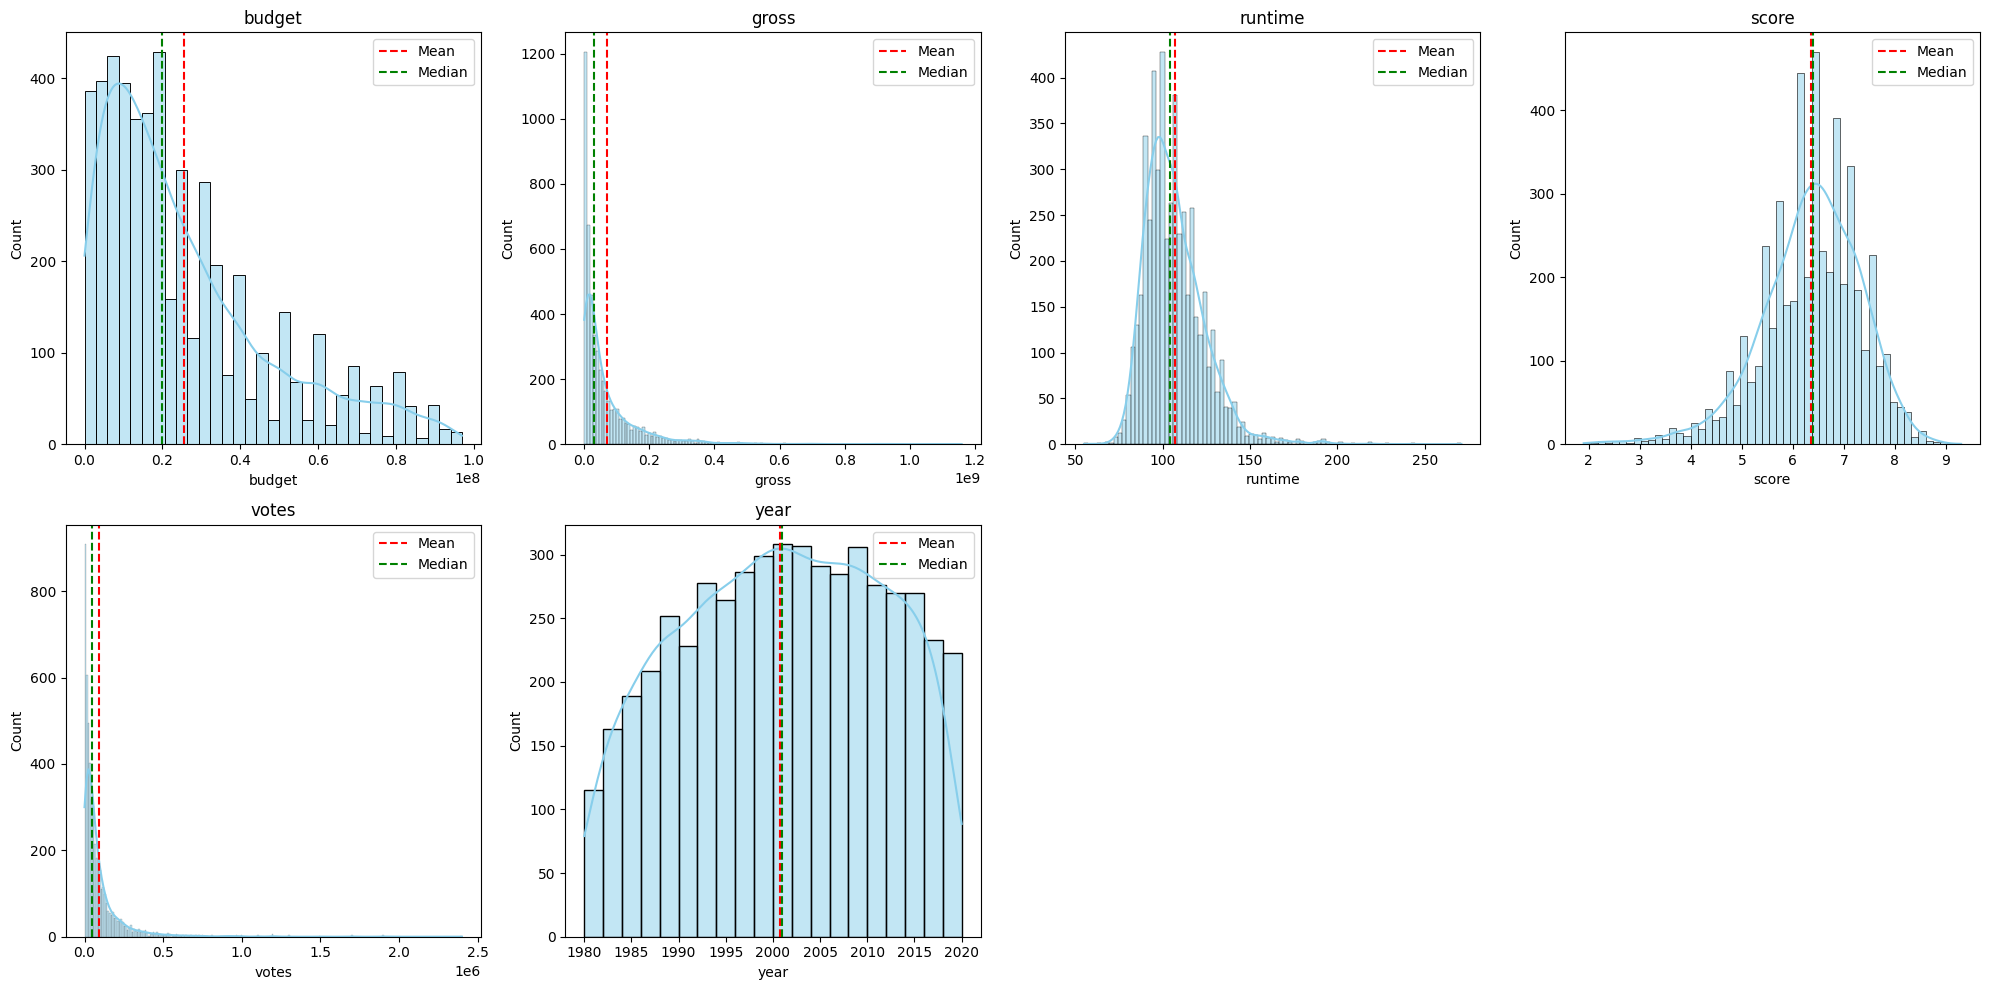

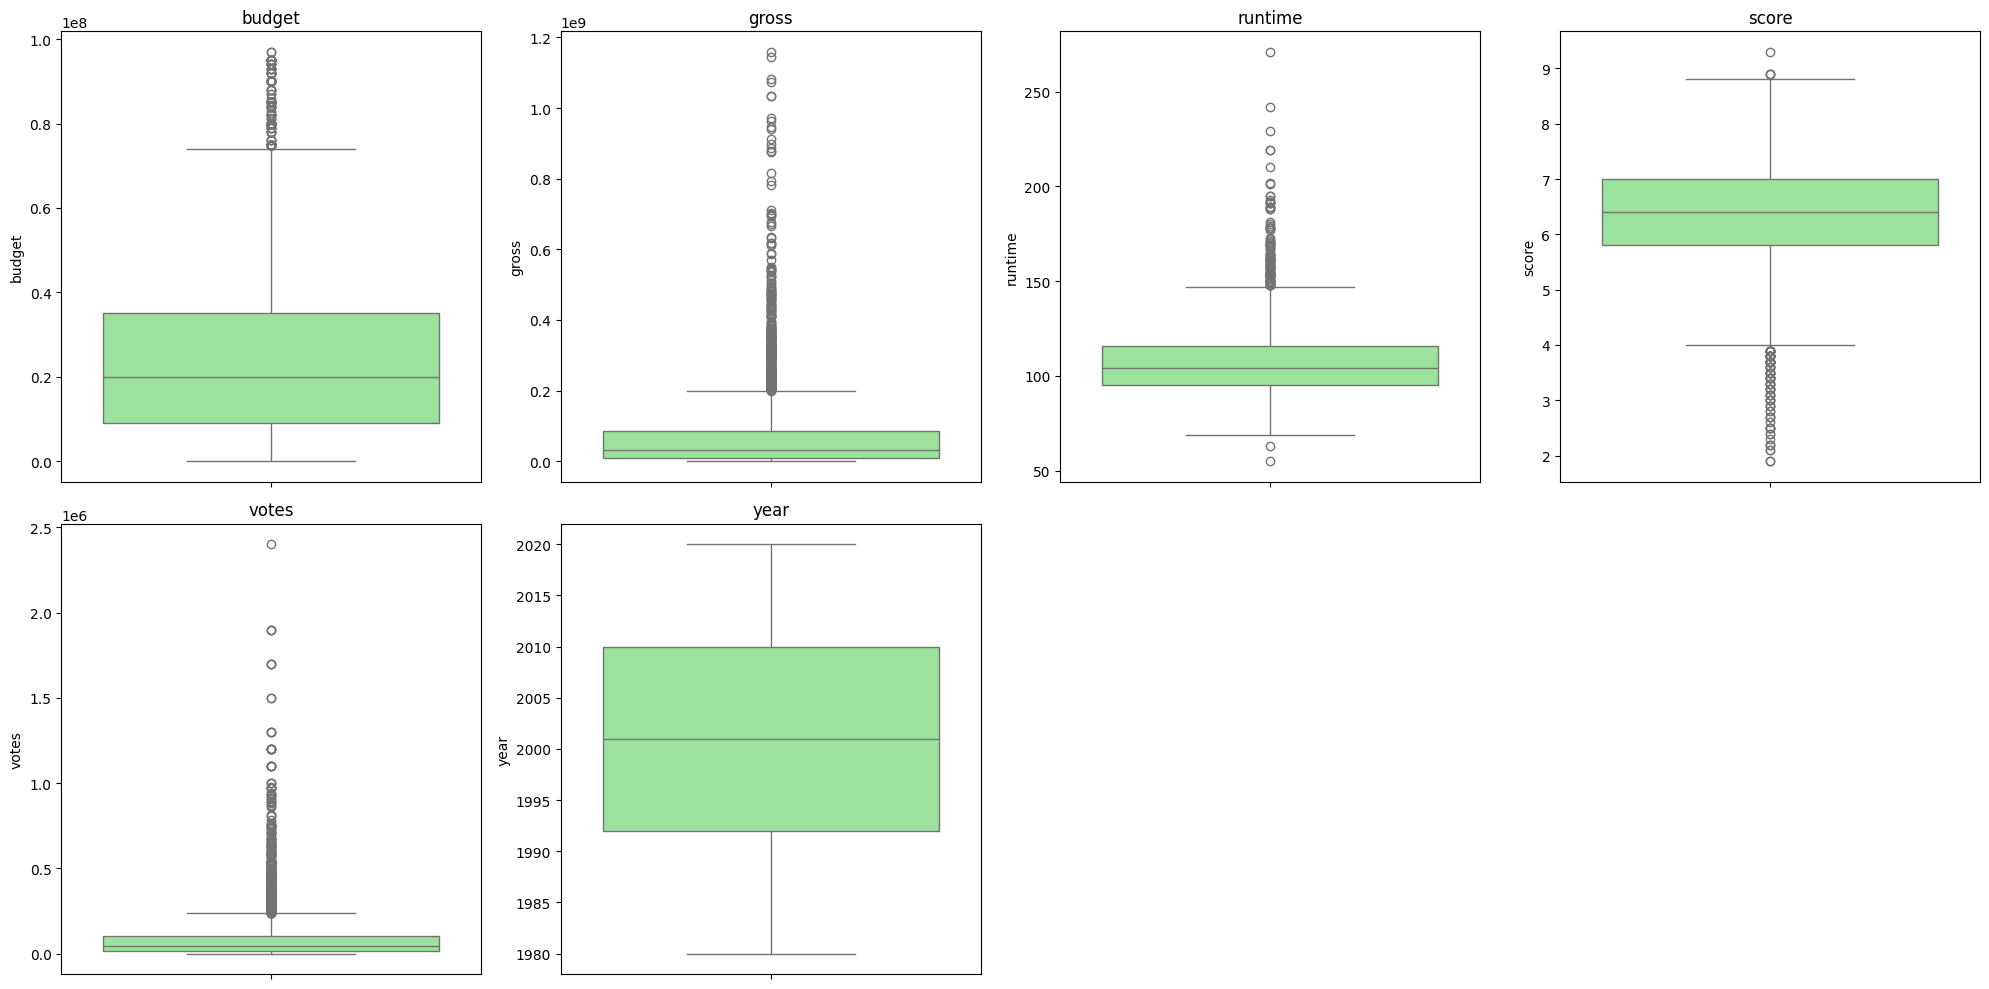

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['budget', 'gross', 'runtime', 'score', 'votes', 'year']

fig, axes = plt.subplots(2, 4, figsize=(20,10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='skyblue')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label='Median')
    axes[i].set_title(col)
    axes[i].legend()

for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20,10))  
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [22]:
outlier_cols = ['budget', 'gross', 'votes']
outliers_df = pd.DataFrame()

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col} outliers: {len(outliers)} rows")
    outliers_df = pd.concat([outliers_df, outliers])

outliers_df = outliers_df.drop_duplicates()
print(f"Total outlier movies: {len(outliers_df)}")


budget outliers: 272 rows
gross outliers: 419 rows
votes outliers: 460 rows
Total outlier movies: 801


In [23]:
total_gross = df['gross'].sum()
outlier_gross = outliers_df['gross'].sum()
percentage = (outlier_gross / total_gross) * 100
print(f"Percentage of total revenue from outliers: {percentage:.2f}%")


Percentage of total revenue from outliers: 52.59%


In [24]:
print(outliers_df[['name','budget','gross','votes']].head(5))

                           name      budget        gross     votes
2054             Batman Returns  80000000.0  266892996.0  280000.0
2262           Last Action Hero  85000000.0  137298489.0  141000.0
2469                   Maverick  75000000.0  183031272.0  104000.0
2656  Die Hard with a Vengeance  90000000.0  366101666.0  370000.0
2701                Judge Dredd  90000000.0  113493481.0  112000.0


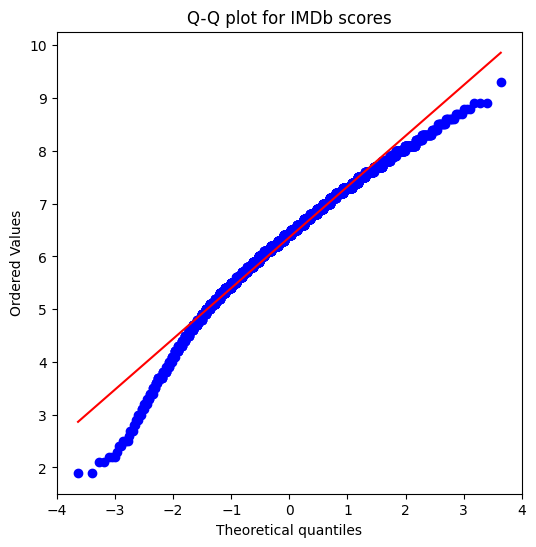

In [25]:
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(df['score'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q plot for IMDb scores")
plt.show()


In [26]:
mean = df['score'].mean()
std = df['score'].std()
ratings = df['score'].dropna()

within_1sd = ((ratings >= mean - std) & (ratings <= mean + std)).mean() * 100
within_2sd = ((ratings >= mean - 2*std) & (ratings <= mean + 2*std)).mean() * 100
within_3sd = ((ratings >= mean - 3*std) & (ratings <= mean + 3*std)).mean() * 100

print(f"Within 1 SD: {within_1sd:.2f}%")
print(f"Within 2 SD: {within_2sd:.2f}%")
print(f"Within 3 SD: {within_3sd:.2f}%")


Within 1 SD: 72.49%
Within 2 SD: 95.68%
Within 3 SD: 99.05%


           budget     gross   runtime     score     votes      year
budget   1.000000  0.528344  0.249716 -0.016068  0.270090  0.245682
gross    0.528344  1.000000  0.166059  0.201941  0.573627  0.200984
runtime  0.249716  0.166059  1.000000  0.419896  0.277890  0.029998
score   -0.016068  0.201941  0.419896  1.000000  0.462856  0.040694
votes    0.270090  0.573627  0.277890  0.462856  1.000000  0.157971
year     0.245682  0.200984  0.029998  0.040694  0.157971  1.000000


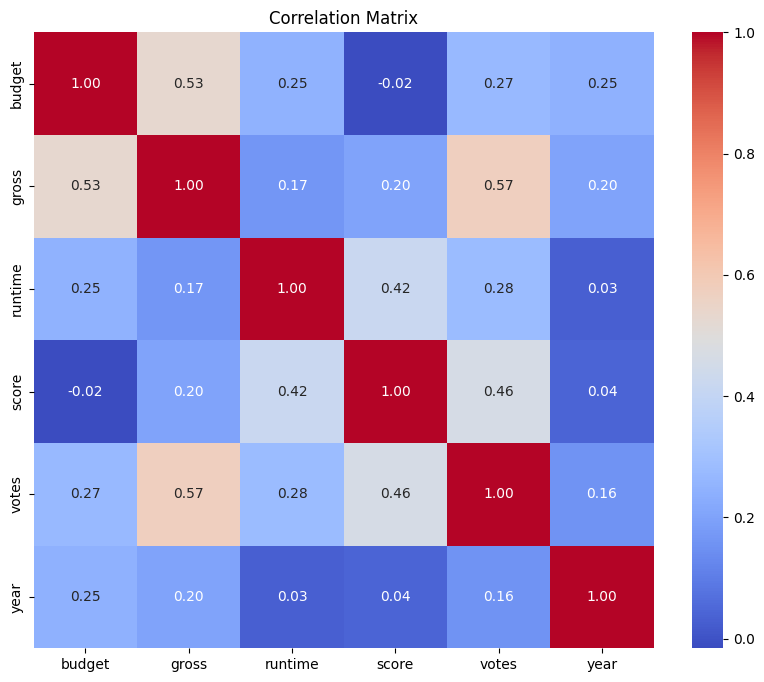

In [27]:
numerical_cols = ['budget', 'gross', 'runtime', 'score', 'votes', 'year']

corr_matrix = df[numerical_cols].corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

<Figure size 1200x1000 with 0 Axes>

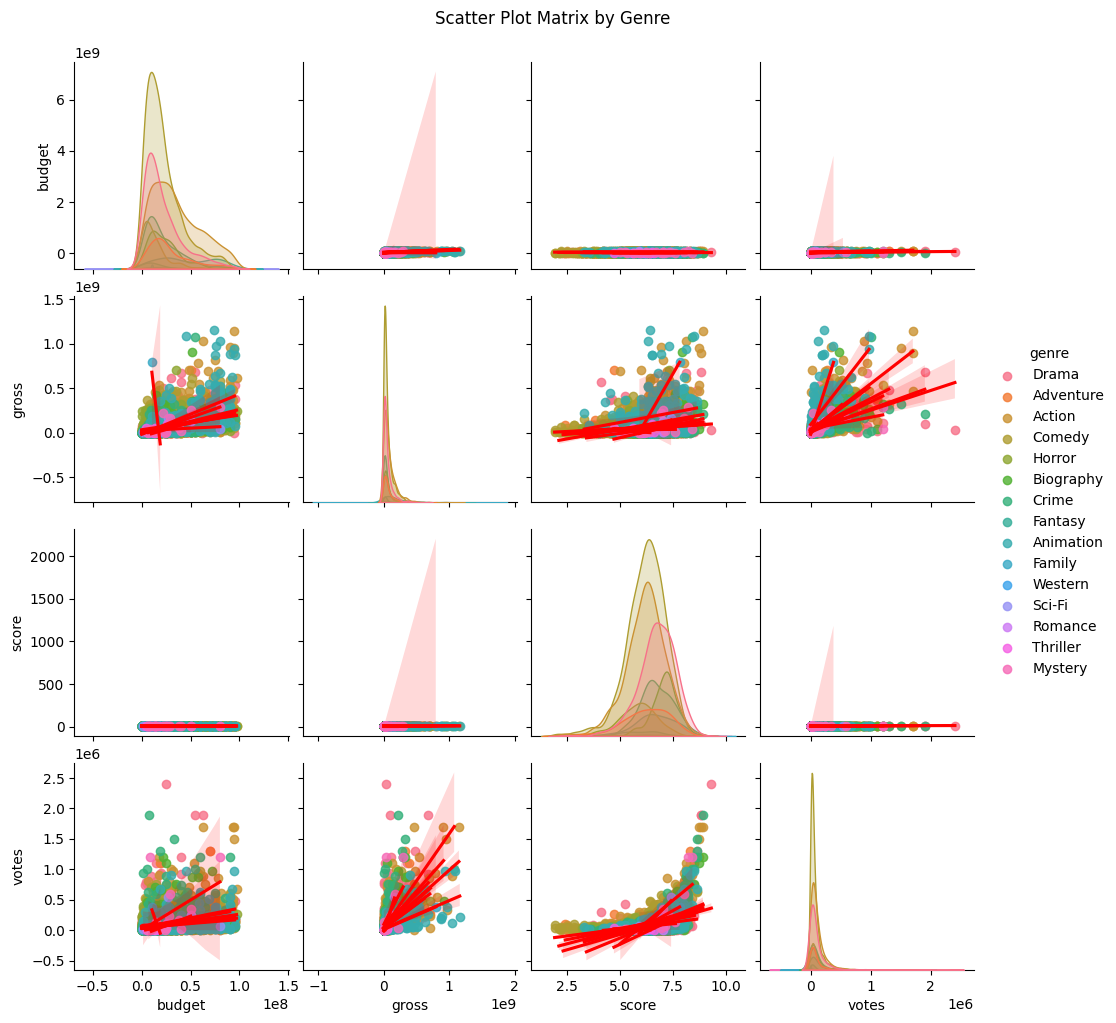

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

scatter_cols = ['budget', 'gross', 'score', 'votes']

plt.figure(figsize=(12,10))
sns.pairplot(df[scatter_cols + ['genre']].dropna(), 
             hue='genre', 
             kind='reg',  
             plot_kws={'line_kws':{'color':'red'}})
plt.suptitle("Scatter Plot Matrix by Genre", y=1.02)
plt.show()

In [29]:
import numpy as np

df['profit_margin'] = (df['gross'] - df['budget']) / df['budget']
df['profit_margin'] = df['profit_margin'].replace([np.inf, -np.inf], np.nan)

print(df[['name','budget','gross','profit_margin']].head())


                                             name      budget        gross  \
0                                     The Shining  19000000.0   46998772.0   
1                                 The Blue Lagoon   4500000.0   58853106.0   
2  Star Wars: Episode V - The Empire Strikes Back  18000000.0  538375067.0   
3                                       Airplane!   3500000.0   83453539.0   
4                                      Caddyshack   6000000.0   39846344.0   

   profit_margin  
0       1.473620  
1      12.078468  
2      28.909726  
3      22.843868  
4       5.641057  


correlation: 0.004376165175911377


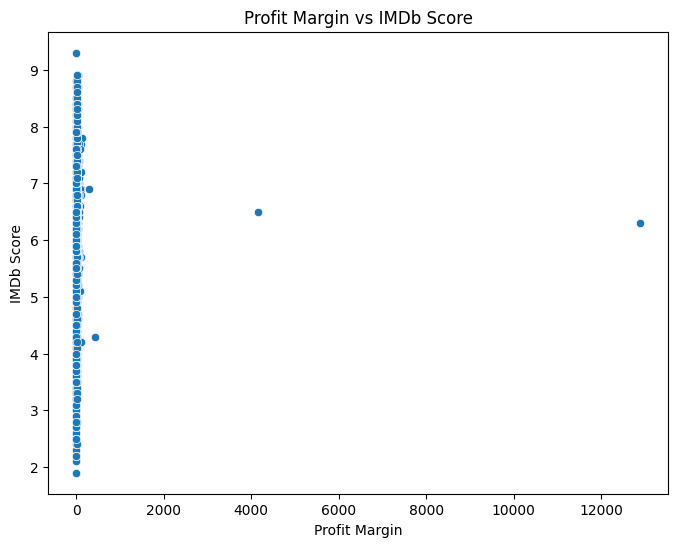

In [46]:
corr = df['profit_margin'].corr(df['score'])
print("correlation:", corr)

plt.figure(figsize=(8,6))
sns.scatterplot(x='profit_margin', y='score', data=df)
plt.title("Profit Margin vs IMDb Score")
plt.xlabel("Profit Margin")
plt.ylabel("IMDb Score")
plt.show()

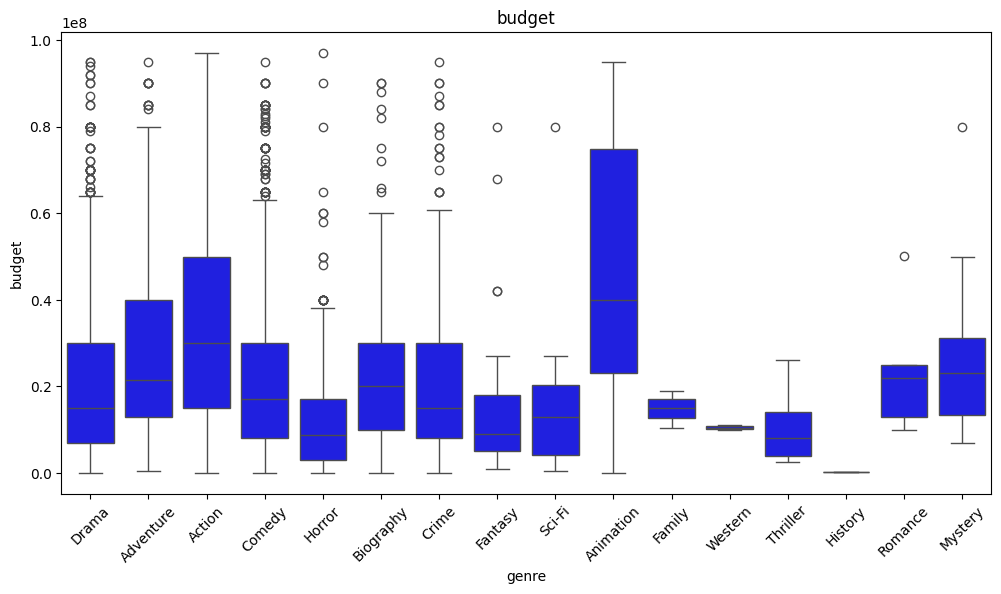

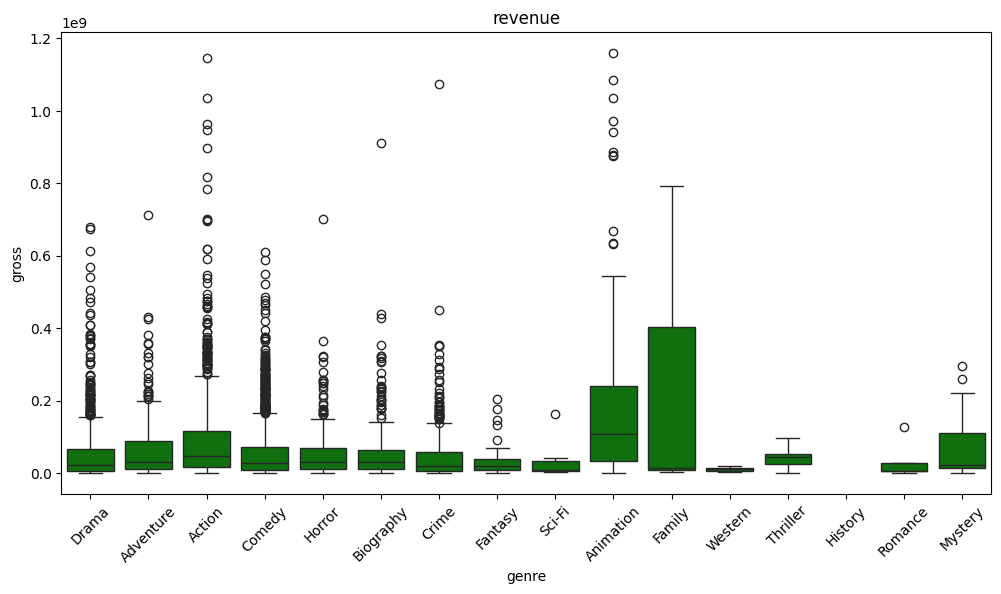

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(x='genre', y='budget', data=df,  color='blue')
plt.title("budget")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='genre', y='gross', data=df, color='green')
plt.title("revenue")
plt.xticks(rotation=45)
plt.show()


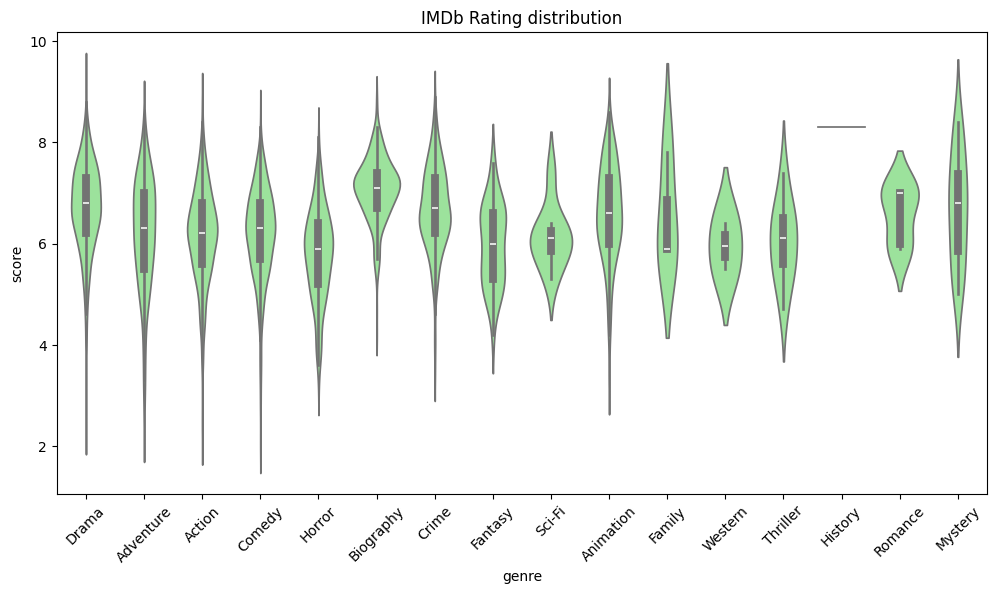

In [32]:
plt.figure(figsize=(12,6))
sns.violinplot(x='genre', y='score', data=df, color='lightgreen')
plt.title("IMDb Rating distribution")
plt.xticks(rotation=45)
plt.show()


In [47]:
df.groupby('genre')['score'].std().sort_values()

genre
Romance      0.576194
Sci-Fi       0.613974
Western      0.636396
Biography    0.636483
Thriller     0.798436
Fantasy      0.800320
Crime        0.846138
Drama        0.896693
Horror       0.897081
Comedy       0.935239
Action       0.958176
Animation    0.966289
Mystery      1.077961
Family       1.096966
Adventure    1.103344
History           NaN
Name: score, dtype: float64

In [49]:
avg_profit_by_genre = df.groupby('genre')['profit_margin'].mean().sort_values(ascending=False)
print(avg_profit_by_genre)

genre
Horror       75.756553
Family       24.539346
Animation     3.315247
Thriller      3.299775
Drama         2.725473
Comedy        2.648666
Adventure     2.056030
Action        1.901164
Biography     1.727754
Mystery       1.599907
Fantasy       1.527100
Crime         1.334083
Sci-Fi        0.995377
Western      -0.006597
Romance      -0.074956
History            NaN
Name: profit_margin, dtype: float64


In [50]:
avg_profit_by_genre = df.groupby('genre')['profit'].mean().sort_values(ascending=False)
print(avg_profit_by_genre)

genre
Family       2.551327e+08
Animation    1.431626e+08
Action       5.328774e+07
Mystery      5.169903e+07
Horror       4.285017e+07
Adventure    3.820391e+07
Comedy       3.580360e+07
Biography    3.490744e+07
Drama        3.276804e+07
Thriller     2.974528e+07
Crime        2.677849e+07
Fantasy      2.038269e+07
Sci-Fi       1.319344e+07
Romance      9.535381e+06
Western     -4.870570e+05
History               NaN
Name: profit, dtype: float64


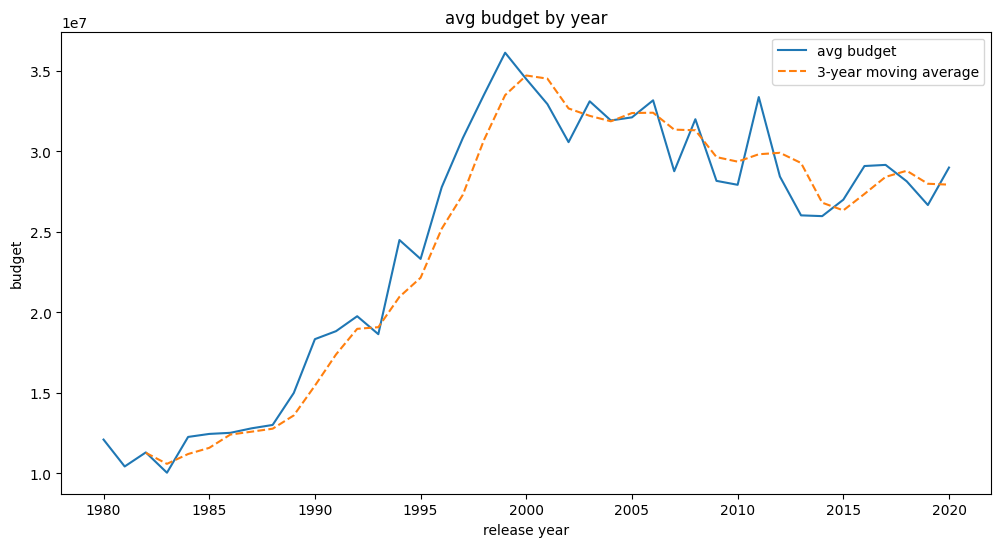

In [36]:
df_year = df.groupby('year')['budget'].mean()
moving_avg_budget = df_year.rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(df_year.index, df_year, label='avg budget')
plt.plot(moving_avg_budget.index, moving_avg_budget, label='3-year moving average', linestyle='--')
plt.xlabel('release year')
plt.ylabel('budget')
plt.title('avg budget by year')
plt.legend()
plt.show()


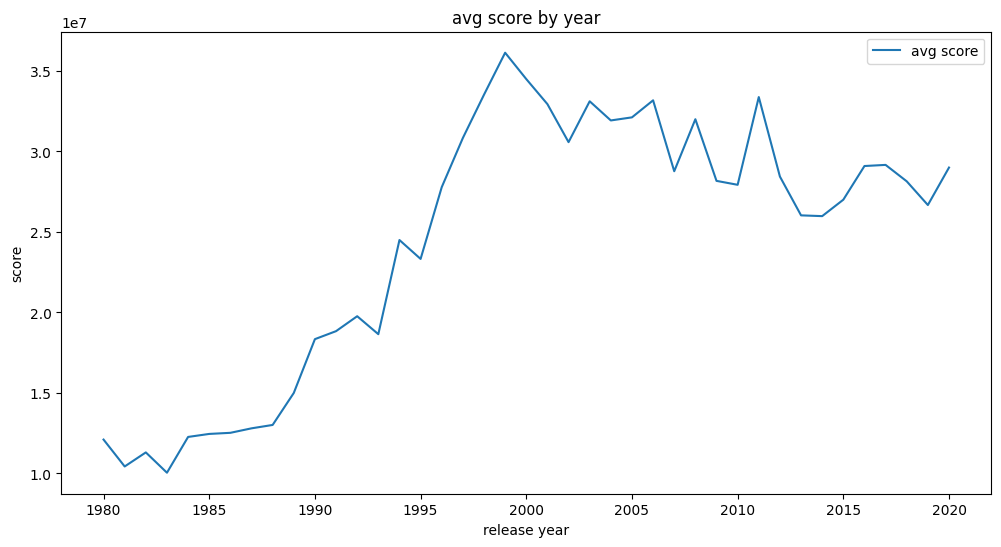

In [37]:
df_score = df.groupby('year')['score'].mean()
moving_avg_budget = df_year.rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(df_year.index, df_year, label='avg score')
plt.xlabel('release year')
plt.ylabel('score')
plt.title('avg score by year')
plt.legend()
plt.show()

In [38]:
df['decade'] = (df['year'] // 10) * 10
decade_avg_rating = df.groupby('decade')['score'].mean()
print(decade_avg_rating)


decade
1980    6.312823
1990    6.367823
2000    6.319305
2010    6.446429
2020    6.022222
Name: score, dtype: float64


In [39]:
top_directors = df['director'].value_counts().head(10)
print(top_directors)


director
Woody Allen          33
Clint Eastwood       31
Steven Soderbergh    22
Steven Spielberg     20
Ron Howard           18
Joel Schumacher      18
Barry Levinson       18
Spike Lee            17
Brian De Palma       16
Directors            16
Name: count, dtype: int64


In [40]:
top_director_stats = df[df['director'].isin(top_directors.index)].groupby('director').agg({
    'score': 'mean',
    'profit_margin': 'mean'
}).sort_values('score', ascending=False)

print(top_director_stats)


                      score  profit_margin
director                                  
Steven Spielberg   7.620000       9.372852
Woody Allen        7.009091       0.812841
Clint Eastwood     6.967742       2.415345
Ron Howard         6.883333       2.545472
Spike Lee          6.747059       3.375108
Directors          6.746667       1.684689
Steven Soderbergh  6.686364       3.003187
Brian De Palma     6.637500       0.749174
Barry Levinson     6.500000       1.717826
Joel Schumacher    6.483333       1.214278
